<section class = "intro">
<p>Through this task, I would like to classify 5 different sign boards used for warnings on road across Victoria. The classes which are being considered for this analysis are <strong>“School zone”</strong>, <strong>“Pedestrian crossing”</strong>, <strong>“No Entry”</strong>, <strong>“No stopping”</strong>,<srtong>“No left or right turn”</srtong>. 
Some of the theoretical challenges include,</p>
<ul>
<li>Model might get confused with the similar colored road signs</li>
<li>Different angles and lighting conditions might prove to be a challenge while classification</li>
</ul>
<p>
Some of the practical challenges include,
</p>
<ul>
<li>There is no open dataset that has the required images for classification</li>
<li>Collecting dataset manually might be hard</li>
<li>If we manage to collect a large dataset, training might require a lot of computational resources</li>
</ul>
<p>
The input to the model will be a pre-processed image. The output should be the class to which it belongs to. 
The target classes are:
</p>
<ul>
<li>School zone</li>
<li>Pedestrian crossing</li>
<li>No Entry</li>
<li>No stopping</li>
<li>No left or right turn</li>
</section>

<section class = "intr0">
<p>The series of tasks carried out as part of this project are</p>
<ul>
    <li>Dataset collection from various sources across web</li>
    <li>Development of a simple CNN and testing it against validation set</li>
    <li>Create new dataset with more images with the help of image augmentation</li>
    <li>Retrain and re-evaluate another CNN with same architecture</li>
    <li>Compare the performance of both the models under equal time</li>
    <li>Find the patterns between the misclassified images</li>
    <li>Collect a new dataset with the help of google real time view</li>
    <li>Check how well the model is generalized and make improvements</li>
</ul>
</section>

<section class="intro">
<h3>Dataset Collection and Processing</h3>

For this task, we need a dataset with images representing each class. There was no open dataset available for this cause. Hence, The images are to be collected and labelled manually. 

For this task, I am looking to collect around 50 images for each class considering the availability of images across web.

To evaluate the model performance, we can monitor the metrics such as training accuracy, training loss, validation accuracy, validation loss, accuracy, precision and recall to check how the model has performed and also to ensure that the model doesn’t overfit.  


In [3]:
# path for combined dataset 
data_dir = 'data/train'  
# ImageDataGenerator for loading images without augmenting
datagen = ImageDataGenerator(
    rescale=1./255,   #rescaling
    validation_split=0.2  #80-20 split for training and validation
)
# Load train and validation datasets
train_generator = datagen.flow_from_directory(
    data_dir, 
    target_size=(128, 128),
    batch_size=32, 
    class_mode='categorical', 
    subset='training' 
)
validation_generator = datagen.flow_from_directory(
    data_dir, 
    target_size=(128, 128), 
    batch_size=32, 
    class_mode='categorical', 
    subset='validation' 
)

Found 166 images belonging to 5 classes.
Found 39 images belonging to 5 classes.


</section>

<section class ="intro">
    <h3>Development of CNN</h3>

/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/100


/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 470ms/step - accuracy: 0.2911 - loss: 1.8020 - val_accuracy: 0.1795 - val_loss: 1.6096
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.2281 - loss: 1.5871 - val_accuracy: 0.1538 - val_loss: 1.5798
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 451ms/step - accuracy: 0.2886 - loss: 1.5520 - val_accuracy: 0.2564 - val_loss: 1.5051
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 463ms/step - accuracy: 0.3584 - loss: 1.4399 - val_accuracy: 0.4359 - val_loss: 1.3757
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - accuracy: 0.3891 - loss: 1.3077 - val_accuracy: 0.3846 - val_loss: 1.3147
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.4270 - loss: 1.2978 - val_accuracy: 0.4872 - val_loss: 1.2551
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step - accuracy: 0.5601 - loss: 1.0795 - val_accuracy: 0.4359 - val_loss: 1.2169
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - accuracy: 0.4663 - loss: 1.1056 - val_accuracy: 0.5897 - val_loss: 1.1

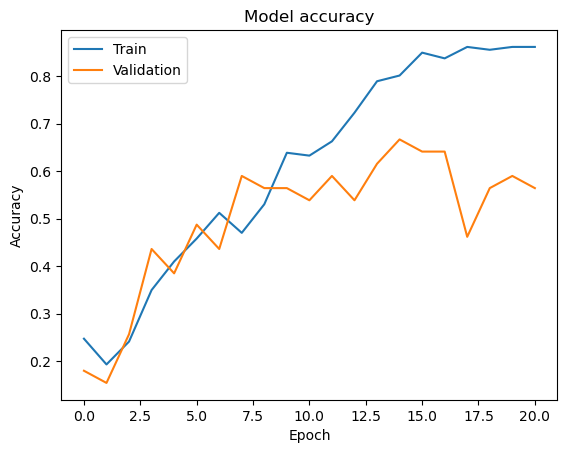

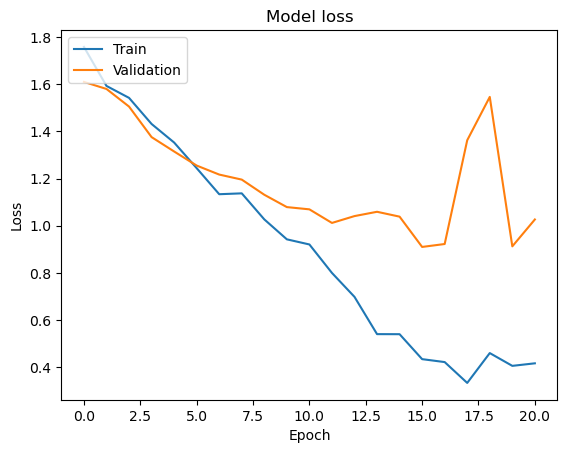

In [4]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  
])
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
# Early stopping callback to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) #patience is set to 5

# Train the model
history = model.fit(
    train_generator, 
    validation_data=validation_generator, 
    epochs=100, 
    callbacks=[early_stopping]
)

The model has been trained with a small dataset of about 200 images and validated. The training accuracy is about 87 and the validation accuracy is just 56% which tells that the model is not good at predicting unseen data. The validation loss is also high when compared with the training loss.

In [ ]:
</section>

The below cell was executed only once since it generates and saves the augmented images in a directory. This has been done so that, the images need not be augmented every single time when needed.

In [ ]:
# Directory to save augmented images
augmented_save_dir = 'augmented_images/'
os.makedirs(augmented_save_dir, exist_ok=True)

# Augmentation pipeline
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,  # Increased zoom
    horizontal_flip=True,
    fill_mode='nearest'
)

# Flow from directory and save augmented images
train_generator_augmented = train_datagen_augmented.flow_from_directory(
    data_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=TRAIN_BATCH_SIZE,
    class_mode='categorical',
    save_to_dir=augmented_save_dir,  # Directory where augmented images will be saved
    save_prefix='aug',  # Prefix for the saved images
    save_format='jpeg'  # Image format
)

# Generating and saving images
num_augmented_images = 1000  # Number of augmented images to generate (I set it to 1000 so that the dataset is increased by 5 times)
i = 0
for batch in train_generator_augmented:
    i += 1
    if i > num_augmented_images // TRAIN_BATCH_SIZE: 
        break

Found 924 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Epoch 1/100


/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
2024-09-20 08:14:31.298357: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:103] Profiler session initializing.
2024-09-20 08:14:31.298390: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:118] Profiler session started.
/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 430ms/step - accuracy: 0.2080 - loss: 1.6501 - val_accuracy: 0.2795 - val_loss: 1.4533
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 417ms/step - accuracy: 0.3528 - loss: 1.4098 - val_accuracy: 0.5197 - val_loss: 1.1568
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 421ms/step - accuracy: 0.4640 - loss: 1.1861 - val_accuracy: 0.5240 - val_loss: 1.1269
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 413ms/step - accuracy: 0.6225 - loss: 1.0187 - val_accuracy: 0.6550 - val_loss: 0.9148
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 411ms/step - accuracy: 0.6705 - loss: 0.8634 - val_accuracy: 0.6201 - val_loss: 0.8804
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 408ms/step - accuracy: 0.7618 - loss: 0.6765 - val_accuracy: 0.7205 - val_loss: 0.6878
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.8014 - loss: 0.5274 - val_accuracy: 0.7205 - val_loss: 0.6758
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 410ms/step - accuracy: 0.8725 - loss: 0.3829 - val_accuracy

2024-09-20 08:16:57.429102: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:68] Profiler session collecting data.
2024-09-20 08:16:58.104673: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:130] Profiler session tear down.
2024-09-20 08:16:58.106137: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:147] Collecting XSpace to repository: logdir/plugins/profile/2024_09_20_08_16_58/Jaspers-MacBook-Air.local.xplane.pb


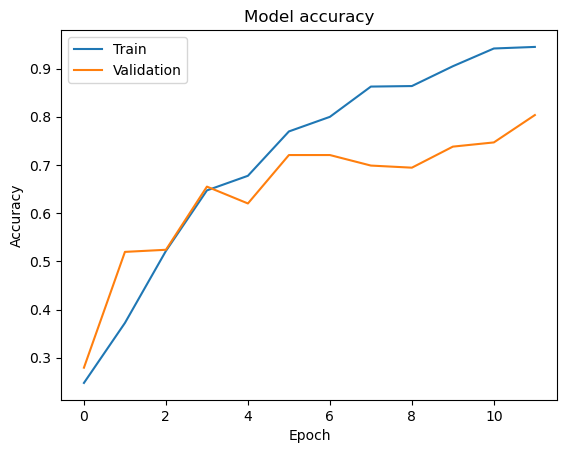

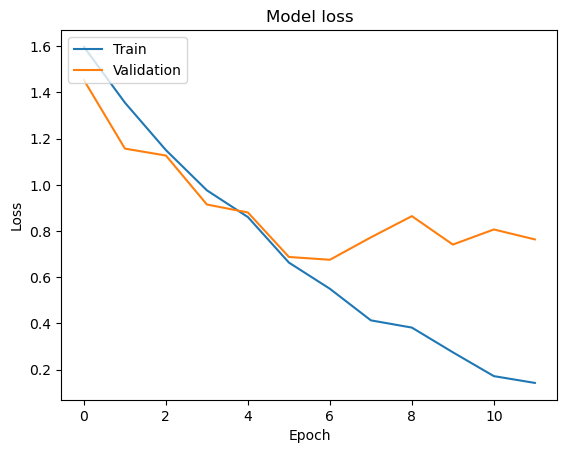

In [15]:
# Set paths and variables
data_dir = 'aug_images/' 
IMAGE_SIZE = 128
TRAIN_BATCH_SIZE = 32

# Define log directory for TensorBoard so that you can view the training metrics
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Load train and validation datasets
train_generator = datagen.flow_from_directory(
    data_dir, 
    target_size=(IMAGE_SIZE, IMAGE_SIZE), 
    batch_size=TRAIN_BATCH_SIZE, 
    class_mode='categorical', 
    subset='training'  
)
validation_generator = datagen.flow_from_directory(
    data_dir, 
    target_size=(IMAGE_SIZE, IMAGE_SIZE), 
    batch_size=TRAIN_BATCH_SIZE, 
    class_mode='categorical', 
    subset='validation' 
)

# Define the CNN model
model_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  
])
# Compile the model
model_aug.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
# Train the model and include TensorBoard profiler callback
history = model_aug.fit(
    train_generator, 
    validation_data=validation_generator, 
    epochs=100, 
    callbacks=[early_stopping, tensorboard_callback]
)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


The model's accuracy has been increased on a whole after using augmented images for training. The training accuracy has been increased to 94% and the validation accuracy is around 80% which is a significant improvement. The loss value has also been lowered which implies that the model has been improved.

The additional timing spent on training the model has improved the performance of the model significantly in terms of predicting more accurately. It's always better to expose more images to the model, so that we get a model which is more generalised.

In [17]:
# Define a time limit in seconds 
time_limit = 120 #(2 minutes)
data_dir = "aug_images"

# Custom Callback to stop training when time limit is exceeded
class TimeLimitCallback(tf.keras.callbacks.Callback):
    """
    This class is implemented to constantly monitor the time consumed after each epoch 
    and when the time is beyond the limit, the training is stopped by setting 
    model.stop_training to True
    """
    def __init__(self, time_limit):
        super(TimeLimitCallback, self).__init__()
        self.time_limit = time_limit
        self.start_time = None
    
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
    
    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.time_limit:
            print(f"Stopping training after {self.time_limit} seconds.")
            self.model.stop_training = True

# Define ImageDataGenerator with augmentation
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
validation_generator_aug = train_datagen_aug.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax') 
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model with a time limit
start_time = time.time()
history_aug = model.fit(
    train_generator_aug,
    validation_data=validation_generator_aug,
    epochs=100, 
    callbacks=[TimeLimitCallback(time_limit)],
    verbose=1
)

aug_training_time = time.time() - start_time
print(f"Training with augmentation took {aug_training_time / 60:.2f} minutes.")


Found 924 images belonging to 5 classes.
Found 229 images belonging to 5 classes.


/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/100


/Users/jasper/Desktop/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 493ms/step - accuracy: 0.2320 - loss: 1.6400 - val_accuracy: 0.3799 - val_loss: 1.3824
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.4256 - loss: 1.3528 - val_accuracy: 0.4541 - val_loss: 1.1941
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 429ms/step - accuracy: 0.4664 - loss: 1.2354 - val_accuracy: 0.4934 - val_loss: 1.1483
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.4793 - loss: 1.2011 - val_accuracy: 0.4847 - val_loss: 1.1241
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.5238 - loss: 1.0961 - val_accuracy: 0.5502 - val_loss: 1.0080
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 427ms/step - accuracy: 0.6404 - loss: 0.9761 - val_accuracy: 0.5939 - val_loss: 0.8643
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.6960 - loss: 0.7862 - val_accuracy: 0.5983 - val_loss: 0.9877
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.6754 - loss: 0.8583 - val_accuracy

In [18]:
# Define ImageDataGenerator without augmentation from the original images directory
data_dir = "data/train"
train_datagen_no_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator_no_aug = train_datagen_no_aug.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_no_aug = train_datagen_no_aug.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model without augmentation, for the same amount of time
start_time = time.time()
history_no_aug = model.fit(
    train_generator_no_aug,
    validation_data=validation_generator_no_aug,
    epochs=100,  # Again, large number; stop based on time
    callbacks=[TimeLimitCallback(time_limit)],
    verbose=1
)
no_aug_training_time = time.time() - start_time
print(f"Training without augmentation took {no_aug_training_time / 60:.2f} minutes.")


Found 166 images belonging to 5 classes.
Found 39 images belonging to 5 classes.
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 472ms/step - accuracy: 0.2140 - loss: 1.6342 - val_accuracy: 0.1795 - val_loss: 1.6120
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step - accuracy: 0.1985 - loss: 1.6096 - val_accuracy: 0.1795 - val_loss: 1.5845
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - accuracy: 0.2519 - loss: 1.5734 - val_accuracy: 0.3077 - val_loss: 1.5574
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 419ms/step - accuracy: 0.3247 - loss: 1.5561 - val_accuracy: 0.1282 - val_loss: 1.5259
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 413ms/step - accuracy: 0.3462 - loss: 1.4233 - val_accuracy: 0.3333 - val_loss: 1.4914
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.3802 - loss: 1.3994 - val_accuracy: 0.4359 - val_loss: 1.3429
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - accuracy: 0.4163 - loss: 1.3379 - val_accuracy: 0.4359 - val_loss: 1.2252
Epoch 8/100
6/6 ━━━━━━━━━━━━━━

In [19]:
# Performance metrics after training with augmentation
aug_final_accuracy = history_aug.history['val_accuracy'][-1]
aug_final_loss = history_aug.history['val_loss'][-1]

# Performance metrics after training without augmentation
no_aug_final_accuracy = history_no_aug.history['val_accuracy'][-1]
no_aug_final_loss = history_no_aug.history['val_loss'][-1]

print(f"With Augmentation - Validation Accuracy: {aug_final_accuracy}, Validation Loss: {aug_final_loss}")
print(f"Without Augmentation - Validation Accuracy: {no_aug_final_accuracy}, Validation Loss: {no_aug_final_loss}")

With Augmentation - Validation Accuracy: 0.6943231225013733, Validation Loss: 0.7773334980010986
Without Augmentation - Validation Accuracy: 0.5897436141967773, Validation Loss: 3.0156593322753906


After setting equal time for both the training, we could find that still the model trained with augmented dataset is performing better than the other model. In this run, the augmented model ran for 10 epochs and the other model ran for 49 epochs. The seconds can be altered, but in most of the cases the observed result holds.

The metrics training accuracy is more in case of non-augmented model which is equal to one implying over-fitting. The validation accuracy is low (58%) when compared with the augmented model (70%). Also the validation loss is 3.015 which is too high while compared with 0.777 suggesting that the non-augmented model performs poor even under similar training time in this scenario.

In [21]:
# Initialize lists to store incorrectly classified images and labels
incorrect_images = []
incorrect_true_labels = []
incorrect_pred_labels = []
all_true_labels = []
all_pred_labels = []
class_labels = {v: k for k, v in train_generator.class_indices.items()}
#Loop through the validation 
for i in range(len(validation_generator)):
    # Get a batch of images and labels
    imgs, labels = validation_generator[i]
    #Predict the labels for the current batch
    predictions = model_aug.predict(imgs)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(labels, axis=1) 
    #Store the true and predicted labels for the classification report
    all_true_labels.extend(true_labels)
    all_pred_labels.extend(predicted_labels)
    #Identify misclassified images
    incorrect_indices = np.where(predicted_labels != true_labels)[0]  
    #Store the misclassified images and labels
    for idx in incorrect_indices:
        incorrect_images.append(imgs[idx])
        incorrect_true_labels.append(class_labels[true_labels[idx]])
        incorrect_pred_labels.append(class_labels[predicted_labels[idx]])
    #Stop if you've processed the entire validation data
    if i == len(validation_generator) - 1:
        break


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [25]:
# Generate and print the classification report
print("\nClassification Report:")
report = classification_report(all_true_labels, all_pred_labels, target_names=list(class_labels.values()))
print(report)



Classification Report:
                     precision    recall  f1-score   support

           no_entry       0.83      0.83      0.83        53
      no_left_right       0.61      0.46      0.52        50
        no_stopping       0.52      0.74      0.61        31
pedestrian_crossing       0.71      0.73      0.72        44
        school_zone       0.88      0.84      0.86        51

           accuracy                           0.72       229
          macro avg       0.71      0.72      0.71       229
       weighted avg       0.73      0.72      0.72       229



In [27]:
#Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

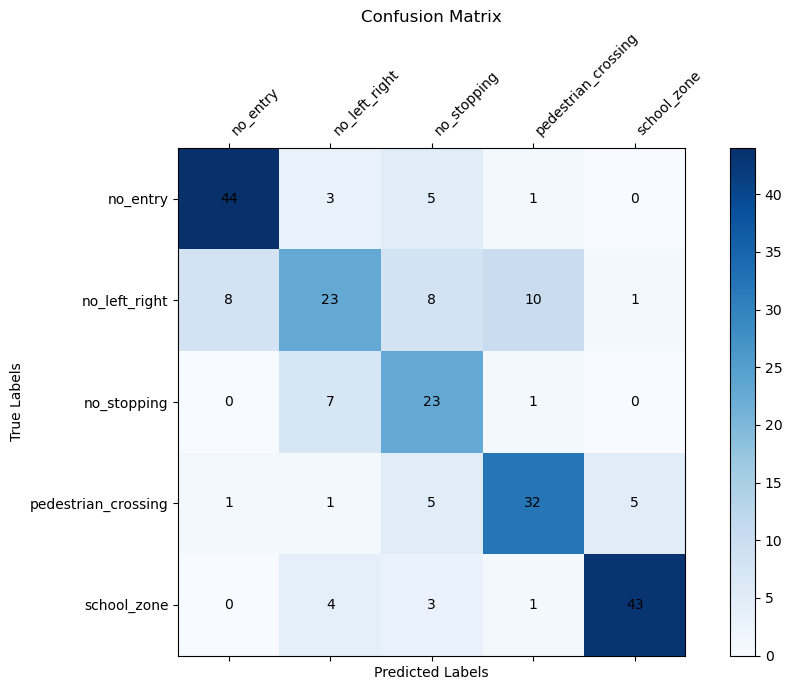

In [29]:
#Plot the matrix
fig, ax = plt.subplots(figsize=(10, 7))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.colorbar(cax)
#Set the labels and ticks
ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels.values(), rotation=45, ha='left')
ax.set_yticklabels(class_labels.values())
#Add text annotations
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f'{val}', ha='center', va='center', color='black')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

Totally 64 images have been misclassified out of 229 images and the list of all the mis-classified images were printed out to see if there is some pattern. Form the classification report printed above, we could observe thatthe model has done well in predicting the images of classes "no_entry" and "school_zone". The mode has been confused between classifying images from the other classes

The above confusion matrix will be helpful in assessing where the model is being wrong.
1)Some of the images from "no_left_right" are being classified as "pedestrian crossing". This might be due to the reason that the images in both the cases cover up a significant portion of roadway within them.
2)There is also a confusion between "no_stopping" and "no_left_right". This might be due to the presence of more white color in their images.


The best way to improve the model's accuracy is to increase the training dataset with more images in all these classes. Also more specific pre-processing techniques should be introduced so that the predictions are more accurate.

The new test images taken are either from google maps real time view or photographs taken. No images were downloaded from the web source as it was done in previous cases making this a more realistic dataset.

In [35]:
# Load validation dataset from the separate test directory
test_dir = "data/test"
test_datagen = ImageDataGenerator(
    rescale=1./255  #rescaling for test data
)
validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),  
    batch_size=32,
    class_mode='categorical' 
)

# Evaluate the model using the new test generator
new_test_loss, new_test_acc = model_aug.evaluate(validation_generator)
print(f"New Test Loss: {new_test_loss}")
print(f"New Test Accuracy: {new_test_acc}")

Found 112 images belonging to 5 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 658ms/step - accuracy: 0.4232 - loss: 1.4555
New Test Loss: 1.4547796249389648
New Test Accuracy: 0.4017857015132904


The accuracy of the model on the new dataset is around 40% suggesting that the model is confused when it is exposed to new data. The model requires more improvements so that we can obtain a generalised model.

<h3>APPROACH 1</h3>

Use pre-trained model

In this approach we will be using a pre-trained classifier which has been exposed to large amount of images and it can be used as the base model on top of wich a few layers are added so that it can be customised for our cause.

MobileNetV2 model

In [46]:
#Load MobileNetV2 pre-trained on ImageNet, without the top layers
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

#Freeze the base model layers to prevent updates during training
base_model.trainable = False

#Create a new model and add custom layers on top of MobileNetV2
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5), 
    Dense(5, activation='softmax')  
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
#history = model.fit(train_generator, epochs=100, validation_data=validation_generator,callbacks = early_stopping)
history = model.fit(train_generator, epochs=10, validation_data=validation_generator_aug)


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 351ms/step - accuracy: 0.4556 - loss: 1.6520 - val_accuracy: 0.7118 - val_loss: 0.7656
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - accuracy: 0.8831 - loss: 0.3745 - val_accuracy: 0.7031 - val_loss: 0.7926
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.9154 - loss: 0.2420 - val_accuracy: 0.7380 - val_loss: 0.6652
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.9565 - loss: 0.1429 - val_accuracy: 0.7948 - val_loss: 0.5798
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 267ms/step - accuracy: 0.9798 - loss: 0.0884 - val_accuracy: 0.7773 - val_loss: 0.6238
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9911 - loss: 0.0571 - val_accuracy: 0.7729 - val_loss: 0.6642
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.9934 - loss: 0.0370 - val_accuracy: 0.7729 - val_loss: 0.6962
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.9901 - loss: 0.0353 - val_accuracy: 0

In [47]:
# Evaluate the model using the new test generator
new_test_loss, new_test_acc = model.evaluate(validation_generator)
print(f"New Test Loss: {new_test_loss}")
print(f"New Test Accuracy: {new_test_acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 704ms/step - accuracy: 0.6168 - loss: 1.4444
New Test Loss: 1.5732853412628174
New Test Accuracy: 0.6071428656578064


The new test accuracy of the model has been increased from 40 to 60% by adopting a pre-trained model. This approach has been the most successful one while trying to make the model more generalised. The training time was almost the same as previous model training time.

VGG16 model

In [43]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, epochs=100, validation_data=validation_generator_aug,callbacks = early_stopping)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.4118 - loss: 2.3520 - val_accuracy: 0.3929 - val_loss: 1.6288
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.8246 - loss: 0.5138 - val_accuracy: 0.3750 - val_loss: 1.7618
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.9019 - loss: 0.3179 - val_accuracy: 0.4196 - val_loss: 1.7335
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9448 - loss: 0.2079 - val_accuracy: 0.4018 - val_loss: 2.0997
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.9600 - loss: 0.1320 - val_accuracy: 0.4554 - val_loss: 1.8250


In [44]:
# Evaluate the model using the new test generator
new_test_loss, new_test_acc = model.evaluate(validation_generator)
print(f"New Test Loss: {new_test_loss}")
print(f"New Test Accuracy: {new_test_acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3884 - loss: 1.6017
New Test Loss: 1.6287593841552734
New Test Accuracy: 0.3928571343421936


The training time while this model was used was too high and the accuracy achieved is poor. Hence this approach is not suitable for this scenario.

<h3>Approach 2</h3>

Dropout layers and L2 regularization

In [48]:
#Define a CNN model with dropout and L2 regularization
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu',kernel_regularizer=l2(0.001)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(512, activation='relu',kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(5, activation='softmax')  
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_generator, epochs=50, validation_data=validation_generator_aug)


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 653ms/step - accuracy: 0.2134 - loss: 2.4778 - val_accuracy: 0.4017 - val_loss: 1.6919
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 632ms/step - accuracy: 0.4091 - loss: 1.6055 - val_accuracy: 0.4803 - val_loss: 1.4181
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 596ms/step - accuracy: 0.4511 - loss: 1.4139 - val_accuracy: 0.4672 - val_loss: 1.3443
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 590ms/step - accuracy: 0.5309 - loss: 1.2535 - val_accuracy: 0.5153 - val_loss: 1.2574
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 609ms/step - accuracy: 0.6635 - loss: 1.0204 - val_accuracy: 0.5852 - val_loss: 1.3839
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - accuracy: 0.7378 - loss: 0.8968 - val_accuracy: 0.5546 - val_loss: 1.2826
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 605ms/step - accuracy: 0.7633 - loss: 0.8011 - val_accuracy: 0.5895 - val_loss: 1.4740
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 595ms/step - accuracy: 0.7856 - loss: 0.7412 - val_accu

In [49]:
# Evaluate the model using the new test generator
new_test_loss, new_test_acc = model.evaluate(validation_generator)
print(f"New Test Loss: {new_test_loss}")
print(f"New Test Accuracy: {new_test_acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 657ms/step - accuracy: 0.4560 - loss: 2.4261
New Test Loss: 2.3264174461364746
New Test Accuracy: 0.4732142984867096


After adding regularizers, the accuracy has been increased (47%), but there is no significant improvement in this approach too. However, applying l2 regularizer helps prevent overfitting of the model which makes the model more generalized.

<h3>Approach 3</h3>

The below approach defines a ResNet-like architecture using a custom ResidualUnit class for building residual blocks, which helps in training deeper networks by mitigating the vanishing gradient problem. Each residual block consists of two convolutional layers followed by batch normalization and a skip connection that adds the input directly to the output of the block. The model begins with a convolutional layer and adds a series of residual units with increasing filters and strides to capture complex features. Finally, the output is processed through fully connected layers for classification into five classes, with the model compiled using the Adam optimizer and categorical cross-entropy loss.

In [50]:
# Partial Conv2D layer for reuse
DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="SAME", use_bias=False,
                        kernel_regularizer=keras.regularizers.l2(0.01))

# Residual Block class
class ResidualUnit(keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

# ResNet-like model architecture
model = keras.models.Sequential()

# Initial Conv Layer
prev_filters = 64
c = [prev_filters, 2 * prev_filters, 4 * prev_filters, 4 * prev_filters]
model.add(DefaultConv2D(c[0], input_shape=[128, 128, 3]))
model.add(ResidualUnit(c[0], strides=1))

# Add residual blocks with increasing filters and strides
for filters in c[1:]:
    model.add(ResidualUnit(filters, strides=2))

# Pooling and flatten layers
model.add(keras.layers.MaxPooling2D(pool_size=(4, 4)))
model.add(keras.layers.Flatten())

# Fully connected layers
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dropout(0.5))

# Output layer for 5-class classification
model.add(keras.layers.Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Summary
model.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 128, 128, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 128, 128, 64)   │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 64, 64, 128)    │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 32, 32, 256)    │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 16, 16, 256)    │     1,248,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,575,941 (17.46 MB)

 Trainable params: 4,571,845 (17.44 MB)

 Non-trainable params: 4,096 (16.00 KB)

In [51]:
history = model.fit(train_generator, epochs=10, validation_data=validation_generator_aug,callbacks = early_stopping)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 281s 9s/step - accuracy: 0.2402 - loss: 28.7579 - val_accuracy: 0.1878 - val_loss: 107.1856
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 266s 9s/step - accuracy: 0.4064 - loss: 18.5913 - val_accuracy: 0.3100 - val_loss: 16.9200
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 206s 7s/step - accuracy: 0.4755 - loss: 16.0116 - val_accuracy: 0.3450 - val_loss: 14.3997
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 178s 6s/step - accuracy: 0.4981 - loss: 13.5287 - val_accuracy: 0.1747 - val_loss: 12.3099
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 189s 7s/step - accuracy: 0.5443 - loss: 11.2893 - val_accuracy: 0.1965 - val_loss: 10.4027


In [52]:
# Evaluate the model using the new test generator
new_test_loss, new_test_acc = model.evaluate(validation_generator)
print(f"New Test Loss: {new_test_loss}")
print(f"New Test Accuracy: {new_test_acc}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2061 - loss: 79.5993
New Test Loss: 77.67998504638672
New Test Accuracy: 0.2053571492433548


Using this methodology, the training time was too hugh and the model has performed poorly.